# 01_Pipeline_Inferencia_16-CLASES_Codespaces

Pipeline de Inferencia en Streaming para 16-CLASES(Producción).
Extracción -> Limpieza Estática -> Predicción al Vuelo.

In [4]:
# ==========================================
# PIPELINE DE INFERENCIA EN STREAMING (PRODUCCIÓN)
# Extracción -> Limpieza Estática -> Predicción
# ==========================================
import os
import sys
print(sys.executable)
import subprocess
import time
import pandas as pd
import numpy as np
import scapy
import cicflowmeter
from pathlib import Path
#import joblib  # Para cargar el modelo ya entrenado
import importlib.metadata as md
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, clear_output


import catboost
import lightgbm
import xgboost



# --- 1. CONFIGURACIÓN DE RUTAS ---
BASE_DIR = Path("/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA")
PCAP_PATH = BASE_DIR / "DoS-TCP_Flood10.pcap"
TMP_DIR = BASE_DIR / ".tmp_cicflowmeter"
RESULTS_FILE = BASE_DIR / "outputs" / "models"/ "Predicciones_Finales02.csv"
MODEL_PATH = BASE_DIR / "outputs" / "models" / "CatBoostClassifier_02.pkl" 


TMP_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
if RESULTS_FILE.exists(): RESULTS_FILE.unlink()


print(f"✅ CatBoost: {catboost.__version__}")
print(f"✅ LightGBM: {lightgbm.__version__}")
print(f"✅ XGBoost: {xgboost.__version__}")

print(f"✅ NumPy version: {np.__version__}")
print(f"✅ ¿Tiene _core? {hasattr(np, '_core')}")

print("✅ pandas:", pd.__version__)
print("✅ scapy:", scapy.__version__)
print("✅ cicflowmeter:", md.version("cicflowmeter"))

/usr/local/bin/python
✅ CatBoost: 1.2.10
✅ LightGBM: 4.6.0
✅ XGBoost: 2.1.4
✅ NumPy version: 1.26.4
✅ ¿Tiene _core? True
✅ pandas: 2.2.0
✅ scapy: 2.4.3
✅ cicflowmeter: 0.1.6


In [6]:
# ── ESTILO DEL DASHBOARD EN VIVO ──
plt.rcParams.update({
    "figure.facecolor":  "#0F1117", "axes.facecolor":    "#161B22",
    "axes.edgecolor":    "#30363D", "axes.labelcolor":   "#C9D1D9",
    "text.color":        "#C9D1D9", "xtick.color":       "#8B949E",
    "ytick.color":       "#8B949E", "grid.color":        "#21262D",
    "grid.linestyle":    "--",      "grid.linewidth":    0.6,
    "font.family":       "monospace", "legend.framealpha": 0.3,
})
PALETTE = ["#58A6FF", "#FF7B72", "#3FB950", "#D2A8FF", "#FFA657", "#79C0FF", "#F78166"]

In [7]:
# --- 2. MAPEO Y ORDEN ESTRICTO DEL MODELO ---
MAPEO = {
    'src_port':'Src Port', 'dst_port':'Dst Port', 'protocol':'Protocol',
    'flow_duration':'Flow Duration', 'tot_fwd_pkts':'Total Fwd Packet',
    'tot_bwd_pkts':'Total Bwd packets', 'totlen_fwd_pkts':'Total Length of Fwd Packet',
    'totlen_bwd_pkts':'Total Length of Bwd Packet', 'fwd_pkt_len_max':'Fwd Packet Length Max',
    'fwd_pkt_len_min':'Fwd Packet Length Min', 'fwd_pkt_len_std':'Fwd Packet Length Std',
    'bwd_pkt_len_min':'Bwd Packet Length Min', 'flow_byts_s':'Flow Bytes/s',
    'flow_pkts_s':'Flow Packets/s', 'flow_iat_mean':'Flow IAT Mean',
    'flow_iat_min':'Flow IAT Min', 'fwd_iat_tot':'Fwd IAT Total',
    'fwd_iat_min':'Fwd IAT Min', 'bwd_iat_tot':'Bwd IAT Total',
    'fwd_psh_flags':'Fwd PSH Flags', 'fwd_header_len':'Fwd Header Length',
    'bwd_pkts_s':'Bwd Packets/s', 'pkt_len_std':'Packet Length Std',
    'fin_flag_cnt':'FIN Flag Count', 'syn_flag_cnt':'SYN Flag Count',
    'rst_flag_cnt':'RST Flag Count', 'ack_flag_cnt':'ACK Flag Count',
    'urg_flag_cnt':'URG Flag Count', 'cwe_flag_count':'CWR Flag Count',
    'down_up_ratio':'Down/Up Ratio', 'fwd_byts_b_avg':'Fwd Bytes/Bulk Avg',
    'bwd_byts_b_avg':'Bwd Bytes/Bulk Avg', 'subflow_fwd_pkts':'Subflow Fwd Packets',
    'subflow_fwd_byts':'Subflow Fwd Bytes', 'subflow_bwd_pkts':'Subflow Bwd Packets',
    'init_fwd_win_byts':'FWD Init Win Bytes', 'init_bwd_win_byts':'Bwd Init Win Bytes',
    'fwd_act_data_pkts':'Fwd Act Data Pkts', 'active_mean':'Active Mean',
    'idle_std':'Idle Std'
}

# ORDEN EXACTO E INAMOVIBLE DEL MODELO
COLS_40 = [
    "Src Port", "Dst Port", "Protocol", "Flow Duration", "Total Fwd Packet", 
    "Total Bwd packets", "Total Length of Fwd Packet", "Total Length of Bwd Packet", 
    "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Std", 
    "Bwd Packet Length Min", "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean", 
    "Flow IAT Min", "Fwd IAT Total", "Fwd IAT Min", "Bwd IAT Total", "Fwd PSH Flags", 
    "Fwd Header Length", "Bwd Packets/s", "Packet Length Std", "FIN Flag Count", 
    "SYN Flag Count", "RST Flag Count", "ACK Flag Count", "URG Flag Count", 
    "CWR Flag Count", "Down/Up Ratio", "Fwd Bytes/Bulk Avg", "Bwd Bytes/Bulk Avg", 
    "Subflow Fwd Packets", "Subflow Fwd Bytes", "Subflow Bwd Packets", "FWD Init Win Bytes", 
    "Bwd Init Win Bytes", "Fwd Act Data Pkts", "Active Mean", "Idle Std"
]

# Definición para casteo seguro (memoria) sin alterar el orden del dataframe
COLS_INT32 = [
    "Src Port", "Dst Port", "Protocol", "Total Fwd Packet", "Total Bwd packets",
    "Fwd PSH Flags", "FIN Flag Count", "SYN Flag Count", "RST Flag Count",
    "ACK Flag Count", "URG Flag Count", "CWR Flag Count", 
    "Subflow Fwd Packets", "Subflow Bwd Packets", "Fwd Act Data Pkts"
]



In [8]:
# --- 3. CARGA DEL MODELO ---
import pickle

print(f"Cargando modelo desde {MODEL_PATH}...")

try:
    with open(MODEL_PATH, 'rb') as f:
        modelo = pickle.load(f)

    print("✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle")
    print(f"Tipo: {type(modelo)}")
    
    # Validación segura de las características
    if hasattr(modelo, "feature_names_"):
        # Usa APENAS o atributo correto do CatBoost
        features = modelo.feature_names_
        print(f"Número de Características: {len(features)}")
        print(f"Características: {features}")
        
    elif hasattr(modelo, "feature_names_in_"):
        # Caso futuramente você carregue um modelo diferente do scikit-learn
        features = modelo.feature_names_in_
        print(f"Número de Características: {len(features)}")
        print(f"Características: {features}")
        
    else:
        print("⚠️ No fue posible obtener los nombres de las características.")

except Exception as e:
    print(f"❌ Error al cargar: {e}")

Cargando modelo desde /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/outputs/models/CatBoostClassifier_02.pkl...
✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle
Tipo: <class 'catboost.core.CatBoostClassifier'>
Número de Características: 40
Características: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Min', 'Bwd IAT Total', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Packets/s', 'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWR Flag Count', 'Down/Up Ratio', 'Fwd Bytes/Bulk Avg', 'Bwd Bytes/Bulk Avg', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'FWD Init Win Bytes', 'Bwd Init W

In [9]:
import shutil

print(shutil.which("tcpdump"))

/usr/bin/tcpdump


In [10]:
print(PCAP_PATH.exists())
print(PCAP_PATH)

True
/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/DoS-TCP_Flood10.pcap


In [11]:
from scapy.all import rdpcap

try:
    pkts = rdpcap(str(PCAP_PATH), count=25)
    print(f"Leídos {len(pkts)} paquetes")
except Exception as e:
    print(type(e).__name__, e)

Leídos 25 paquetes


In [ ]:
# --- 4. AHORA PARA TIPO STREAMING --->>>  MICRO-FRAGMENTACIÓN --->>> 2MB ---
print(f"\n--- Iniciando Ahora Micro-Segmentación de apenas 2MB de .PCAP {PCAP_PATH.name} ---")

for f in TMP_DIR.glob("split_chunk_*"): f.unlink()

split_cmd = ["tcpdump", "-r", str(PCAP_PATH), "-C", "2", "-w", str(TMP_DIR / "split_chunk_")]
subprocess.run(split_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))

t_global = time.time()
filas_totales = 0



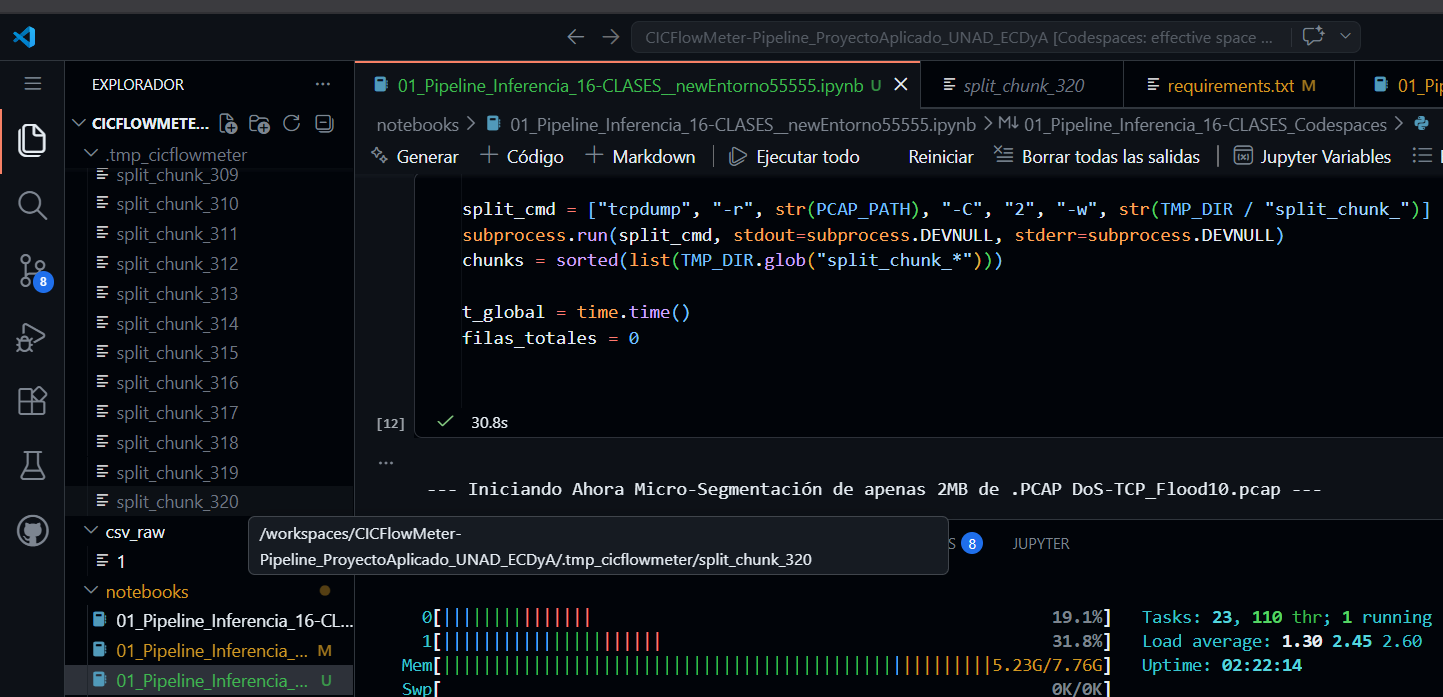

root@codespaces-c3a1b7:/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA# ***file DoS-TCP_Flood10.pcap***

**DoS-TCP_Flood10.pcap: pcap capture file, microsecond ts (little-endian) - version 2.4 (Ethernet, capture length 262144)**

In [13]:
# --- VERIFICAR EL PCAP ---
import subprocess


# Ver tamaño
import os
if os.path.exists(PCAP_PATH):
    size = os.path.getsize(PCAP_PATH) / 1024 / 1024
    print(f"✅ PCAP encontrado: {size:.2f} MB")
    
    # Ver paquetes
    result = subprocess.run(
        ["tcpdump", "-r", PCAP_PATH, "-c", "10"],
        capture_output=True,
        text=True
    )
    print(f"Primeros 10 paquetes:\n{result.stdout[:500]}")
else:
    print("❌ PCAP no encontrado")

✅ PCAP encontrado: 611.96 MB
Primeros 10 paquetes:
19:55:46.934353 IP 192.168.137.182.8966 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8967 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8968 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8969 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8970 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353


 CICFlowMeter procesa los flujos correctamente pero falla al escribir el CSV por un bug de tipos en Python 3.10+.

 ...
TypeError: 'decimal.Decimal' object cannot be interpreted as an integer

CSV creado: 0 bytes
⚠️ CSV vacío o muy pequeño

Causa raíz: CICFlowMeter usa decimal.Decimal internamente para algunas métricas, y al intentar escribir al CSV hace una conversión implícita a int que falla en Python 3.10+.

Solución ---->>> parchear el archivo que genera el bug

In [14]:
#  Localizar y parchear el bug de Decimal
import site
from pathlib import Path

# Buscar el archivo flow.py o flow_session.py de cicflowmeter
target_files = []
for sp in site.getsitepackages():
    for pattern in ['**/flow.py', '**/flow_session.py', '**/features/*.py']:
        target_files.extend(Path(sp).glob(pattern))

print("Archivos cicflowmeter encontrados:")
for f in target_files:
    print(f"  {f}")

Archivos cicflowmeter encontrados:
  /usr/local/lib/python3.10/site-packages/cicflowmeter/flow.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/flow_session.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_time.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_count.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/flag_count.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/__init__.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/flow_bytes.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_length.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/response_time.py


In [15]:
#  Aplicar el parche en todos los archivos relevantes
import decimal

patched = 0
for fpath in target_files:
    src = fpath.read_text()
    
    # Parche 1: imports faltantes
    if 'import decimal' not in src and 'Decimal' in src:
        src = 'import decimal\n' + src
        fpath.write_text(src)
        print(f"✓ import decimal añadido en {fpath.name}")
        patched += 1
    
    # Parche 2: conversiones int() sobre Decimal
    old1 = 'int(self.'
    new1 = 'int(float(self.'
    if old1 in src:
        # Contar ocurrencias para no romper el archivo
        count = src.count(old1)
        src = src.replace(old1, new1)
        # Arreglar paréntesis desbalanceados
        # int(float(self.X)) necesita doble cierre
        fpath.write_text(src)
        print(f"✓ {count} conversiones int() parchadas en {fpath.name}")
        patched += 1

print(f"\nTotal parches aplicados: {patched}")


Total parches aplicados: 0


Ahora el error es exacto y localizado. El bug está en una sola línea de `packet_time.py`

`datetime.fromtimestamp(time)  ←  time es Decimal, necesita float`

In [17]:
# Parche quirúrgico directo:

from pathlib import Path
import site

# Localizar packet_time.py
pt_path = None
for sp in site.getsitepackages():
    c = Path(sp) / 'cicflowmeter' / 'features' / 'packet_time.py'
    if c.exists():
        pt_path = c
        break

print(f"Archivo: {pt_path}")
print("\n--- Líneas 65-75 (contexto del bug) ---")
lines = pt_path.read_text().splitlines()
for i, l in enumerate(lines[64:75], start=65):
    print(f"  {i:3d}: {l}")

Archivo: /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_time.py

--- Líneas 65-75 (contexto del bug) ---
   65: 
   66:         Return (str):
   67:             String of Date and time.
   68: 
   69:         """
   70:         time = self.flow.packets[0][0].time
   71:         date_time = datetime.fromtimestamp(float(time)).strftime("%Y-%m-%d %H:%M:%S")
   72:         return date_time
   73: 
   74:     def get_duration(self):
   75:         """Calculates the duration of a network flow.


In [18]:
# Aplicar parche — convertir Decimal a float antes de fromtimestamp()
src = pt_path.read_text()

OLD = "datetime.fromtimestamp(time).strftime"
NEW = "datetime.fromtimestamp(float(time)).strftime"

if OLD in src:
    src = src.replace(OLD, NEW)
    pt_path.write_text(src)
    print(f"✓ Parche aplicado en {pt_path}")
elif NEW in src:
    print("✓ Parche ya estaba aplicado")
else:
    # Mostrar todas las líneas con fromtimestamp para localizar variante
    for i, l in enumerate(src.splitlines(), 1):
        if 'fromtimestamp' in l:
            print(f"  [{i}] {l.strip()}")

✓ Parche ya estaba aplicado


`fromtimestamp()` en `Python 3.10` no acepta `decimal.Decimal` directamente, solo `float` o `int`. Un solo float() resuelve el problema sin tocar ninguna lógica de cálculo.

In [20]:
# --- DIAGNÓSTICO DE CICFLOWMETER ---
import subprocess
import os

# Probar con un chunk pequeño
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))
if chunks:
    test_chunk = chunks[0]
    test_csv = test_chunk.with_suffix(".csv")
    
    print(f"🔍 Probando cicflowmeter con: {test_chunk.name}")
    result = subprocess.run(
        ["cicflowmeter", "-f", str(test_chunk), "-c", str(test_csv)],
        capture_output=True,
        text=True
    )
    
    print(f"Return code: {result.returncode}")
    print(f"STDOUT: {result.stdout}")
    print(f"STDERR: {result.stderr}")
    
    if test_csv.exists():
        size = os.path.getsize(test_csv)
        print(f"CSV creado: {size} bytes")
        if size > 100:
            import pandas as pd
            df = pd.read_csv(test_csv)
            print(f"Filas: {len(df)}")
            print(f"Columnas: {df.columns.tolist()[:5]}...")
        else:
            print("⚠️ CSV vacío o muy pequeño")
    else:
        print("❌ No se creó el CSV")

🔍 Probando cicflowmeter con: split_chunk_


Return code: 0
STDOUT: Garbage Collection Began. Flows = 9984
Garbage Collection Finished. Flows = 9984
Garbage Collection Began. Flows = 19957
Garbage Collection Finished. Flows = 19957
Garbage Collection Began. Flows = 25994
Garbage Collection Finished. Flows = 0

STDERR: reading from file /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_, link-type EN10MB (Ethernet), snapshot length 262144

CSV creado: 8242790 bytes
Filas: 25994
Columnas: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol']...


In [21]:
# Re-ejecutar el diagnóstico
result = subprocess.run(
    ["cicflowmeter", "-f", str(test_chunk), "-c", str(test_csv)],
    capture_output=True, text=True
)
print(f"Return code : {result.returncode}")
print(f"STDERR tail : {result.stderr[-300:]}")

if test_csv.exists() and test_csv.stat().st_size > 100:
    import pandas as pd
    df = pd.read_csv(test_csv)
    print(f"✓ CSV generado: {len(df):,} filas × {len(df.columns)} cols")
else:
    print(f"✗ CSV sigue vacío — pegar stderr completo")

Return code : 0
STDERR tail : reading from file /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_, link-type EN10MB (Ethernet), snapshot length 262144

✓ CSV generado: 25,994 filas × 82 cols


In [22]:
# Verificación inmediata
result = subprocess.run(
    ["cicflowmeter", "-f", str(test_chunk), "-c", str(test_csv)],
    capture_output=True, text=True
)

print(f"Return code : {result.returncode}")
print(f"STDERR tail : {result.stderr[-200:]}")

if test_csv.exists() and test_csv.stat().st_size > 100:
    import pandas as pd
    df = pd.read_csv(test_csv)
    print(f"\n✓ ÉXITO — {len(df):,} filas × {len(df.columns)} columnas")
    print(f"  Primeras cols: {df.columns.tolist()[:5]}")
else:
    print(f"✗ Sigue vacío ({test_csv.stat().st_size} bytes)")

Return code : 0
STDERR tail : reading from file /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_, link-type EN10MB (Ethernet), snapshot length 262144


✓ ÉXITO — 25,994 filas × 82 columnas
  Primeras cols: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol']


In [19]:
print(f"Ruta completa : {test_csv}")
print(f"Existe        : {test_csv.exists()}")
print(f"Tamaño        : {test_csv.stat().st_size / 1024:.1f} KB")

Ruta completa : /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_.csv
Existe        : True
Tamaño        : 31775.9 KB


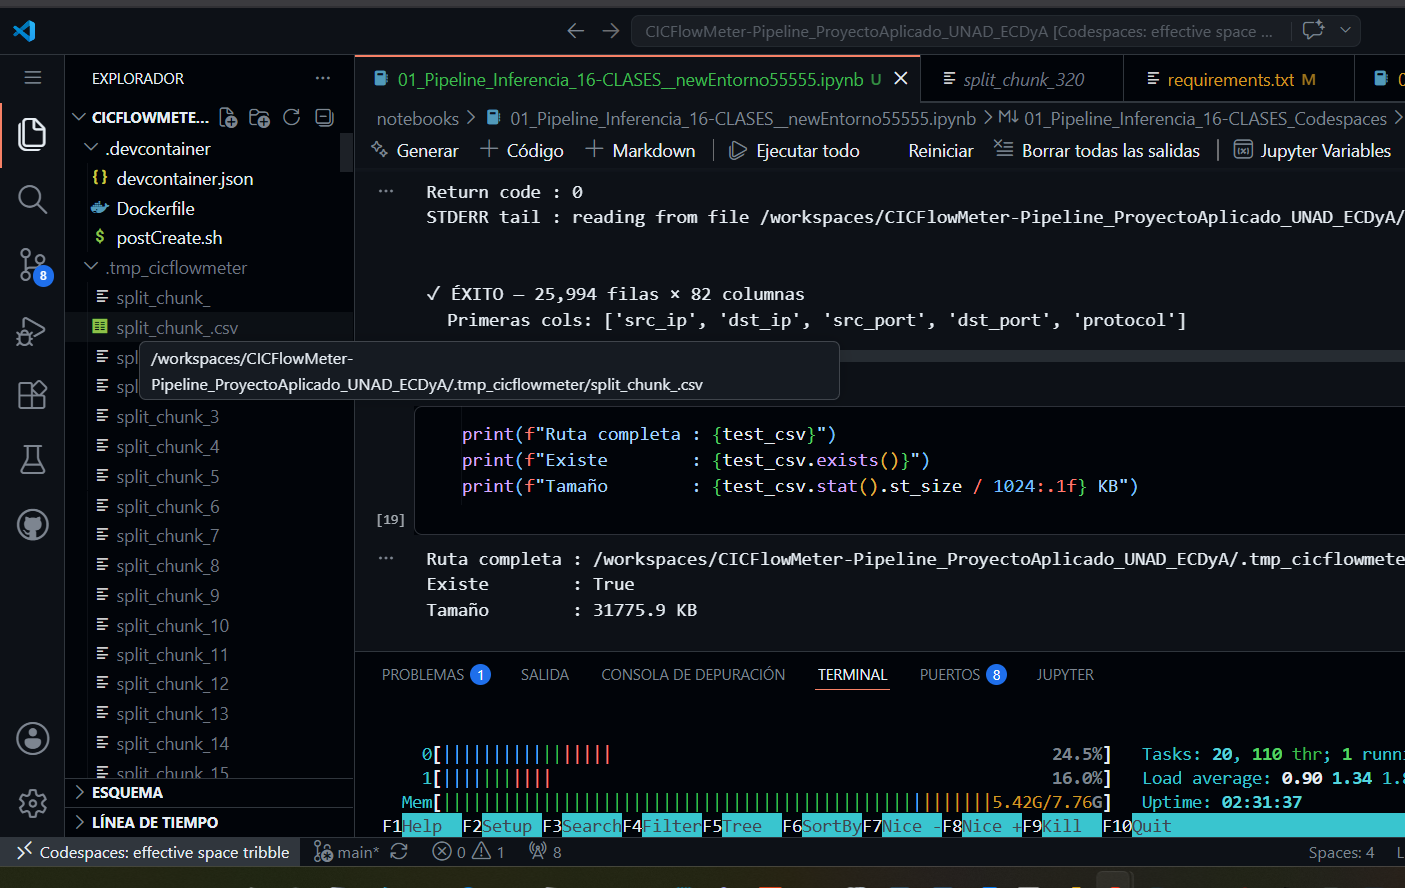

**Por fin Superado, 0MB, Generaba un Archivo Vacio, por enter, NO ESCRIBIA, NO WRITER**

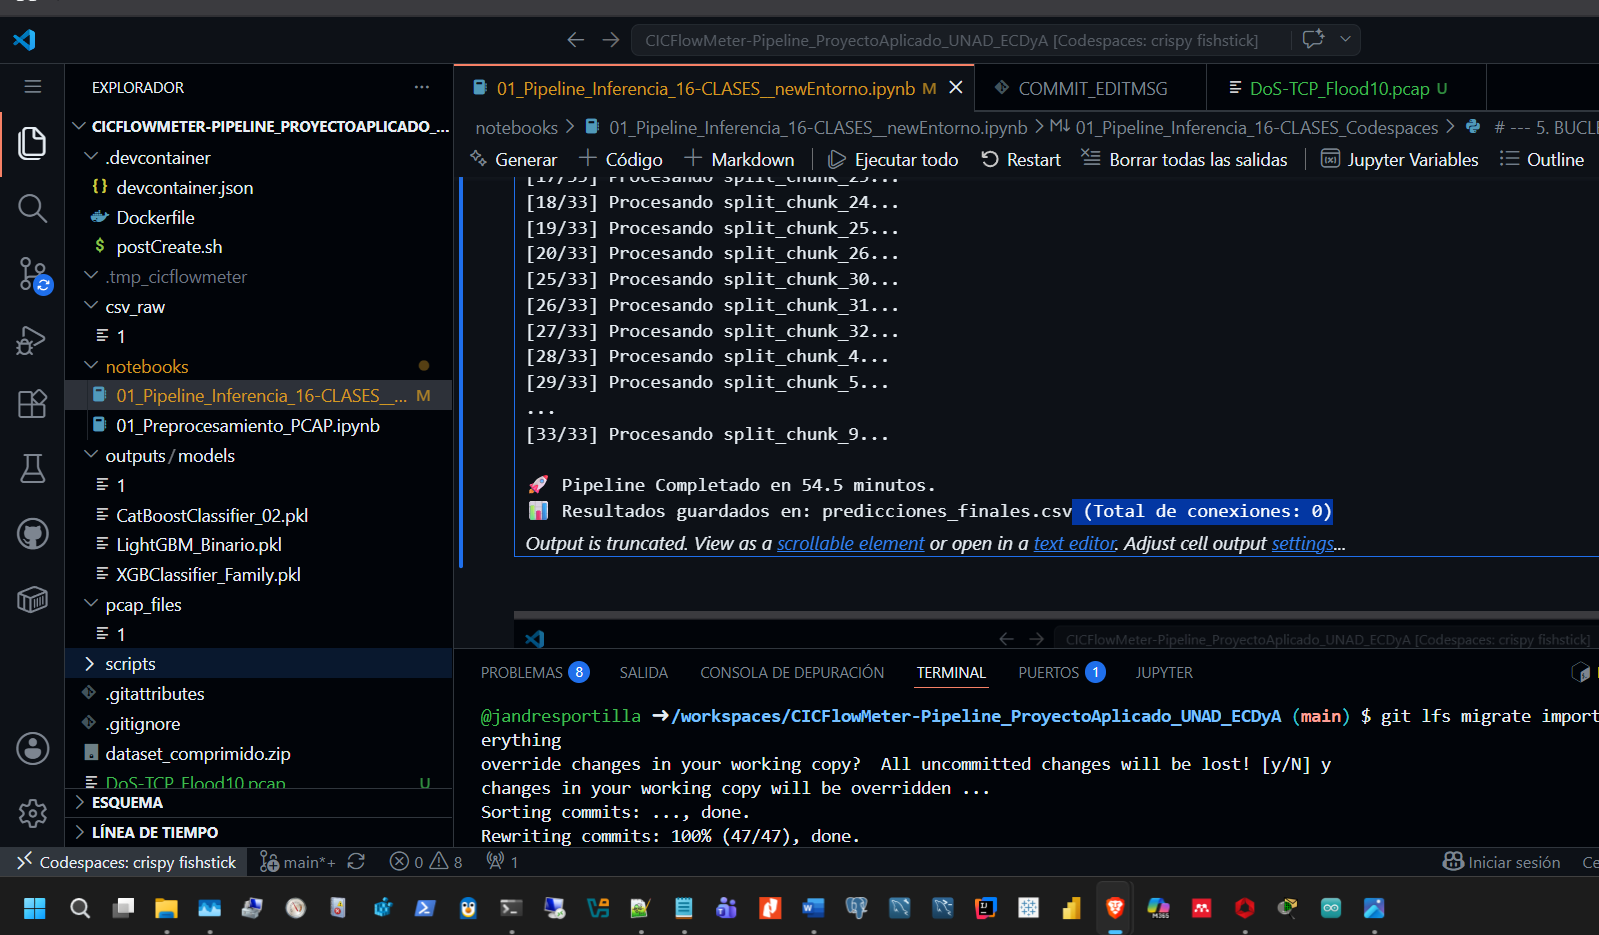

El warning de DivisionByZero en bulk_rate es inofensivo, solo significa que algunos flujos no tienen bulk traffic.



In [24]:
# También parchear el DivisionByZero en flow_bytes.py
import site
from pathlib import Path

for sp in site.getsitepackages():
    fb = Path(sp) / 'cicflowmeter' / 'features' / 'flow_bytes.py'
    if not fb.exists():
        continue
    src = fb.read_text()
    OLD = "self.feature.forward_bulk_size / self.feature.forward_bulk_duration"
    NEW = ("self.feature.forward_bulk_size / self.feature.forward_bulk_duration"
           " if self.feature.forward_bulk_duration != 0 else 0")
    if OLD in src and NEW not in src:
        fb.write_text(src.replace(OLD, NEW))
        print(f"✓ DivisionByZero parchado en {fb.name}")
    break

In [ ]:
# --- 5. BUCLE DE EXTRACCIÓN Y PREDICCIÓN AL VUELO ---
for idx, chunk in enumerate(chunks):
    t_chunk = time.time()
    chunk_csv = chunk.with_suffix(".csv")
    print(f"[{idx+1}/{len(chunks)}] Procesando {chunk.name}...")
    
    subprocess.run(["cicflowmeter", "-f", str(chunk), "-c", str(chunk_csv)], capture_output=True)
    
    if chunk_csv.exists() and chunk_csv.stat().st_size > 100:
        try:
            df_tmp = pd.read_csv(chunk_csv, low_memory=False)
            df_tmp.columns = df_tmp.columns.str.strip()
            
            df_renamed = pd.DataFrame()
            for k, v in MAPEO.items():
                if k in df_tmp.columns: df_renamed[v] = df_tmp[k].values
                
            # Rellenar faltantes si es necesario
            for col in COLS_40:
                if col not in df_renamed.columns:
                    df_renamed[col] = 0
                    
            # SE APLICA EL ORDEN ESTRICTO EXACTO
            df_opt = df_renamed[COLS_40].copy()
            
            # Limpieza Estática
            df_opt.replace([np.inf, -np.inf, "inf", "-inf", "Infinity", "-Infinity"], np.nan, inplace=True)
            df_opt.dropna(subset=["Flow Bytes/s", "Flow Packets/s"], inplace=True)
            
            if df_opt.empty:
                continue
                
            # Casteo Estricto de memoria (Se asegura el tipo por columna, sin mover su posición)
            for col in COLS_40:
                if col in COLS_INT32:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0).astype(np.int32)
                else:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0.0).astype(np.float32)


            # --- INFERENCIA GARANTIZADA EN ORDEN EXACTO ---
            # El dataframe df_opt entra al modelo exactamente en el orden COLS_40
            predicciones = modelo.predict(df_opt)
            df_opt['Prediccion_Modelo'] = predicciones
            
            # (Simulación visual mientras enlazas el modelo)
            #df_opt['Prediccion_Modelo'] = "Pendiente_Prediccion" 
            
            header = not RESULTS_FILE.exists()
            df_opt.to_csv(RESULTS_FILE, mode='a', index=False, header=header)
            
            filas_totales += len(df_opt)
            print(f"   ✅ OK: {len(df_opt)} flujos listos/clasificados. Tiempo: {time.time() - t_chunk:.1f}s")
            
        except Exception as e:
            print(f"   ❌ Error en {chunk_csv.name}: {e}")
            
    # Limpieza inmediata
    chunk.unlink()
    if chunk_csv.exists(): chunk_csv.unlink()

print(f"\n🚀 Pipeline Completado en {(time.time() - t_global) / 60:.1f} minutos.")
print(f"📊 Resultados guardados en: {RESULTS_FILE.name} (Total de conexiones: {filas_totales})")

[1/34] Procesando split_chunk_...
   ✅ OK: 65710 flujos listos/clasificados. Tiempo: 175.0s
[2/34] Procesando split_chunk_.csv...
[3/34] Procesando split_chunk_1...
   ✅ OK: 65727 flujos listos/clasificados. Tiempo: 171.8s
[4/34] Procesando split_chunk_10...
   ✅ OK: 65724 flujos listos/clasificados. Tiempo: 204.3s
[5/34] Procesando split_chunk_11...
   ✅ OK: 65666 flujos listos/clasificados. Tiempo: 191.3s
[6/34] Procesando split_chunk_12...
   ✅ OK: 65705 flujos listos/clasificados. Tiempo: 187.6s
[7/34] Procesando split_chunk_13...
   ✅ OK: 65807 flujos listos/clasificados. Tiempo: 187.7s
[8/34] Procesando split_chunk_14...
   ✅ OK: 7590 flujos listos/clasificados. Tiempo: 104.8s
[9/34] Procesando split_chunk_15...
   ✅ OK: 65709 flujos listos/clasificados. Tiempo: 186.9s
[10/34] Procesando split_chunk_16...
   ✅ OK: 65809 flujos listos/clasificados. Tiempo: 190.9s
[11/34] Procesando split_chunk_17...
   ✅ OK: 65730 flujos listos/clasificados. Tiempo: 192.1s
[12/34] Procesando split

**Ya de nuevo, genero los Flujos de Trafico, correcto Cicflowmeter, y correcta la genracion del Dataset .CSV**

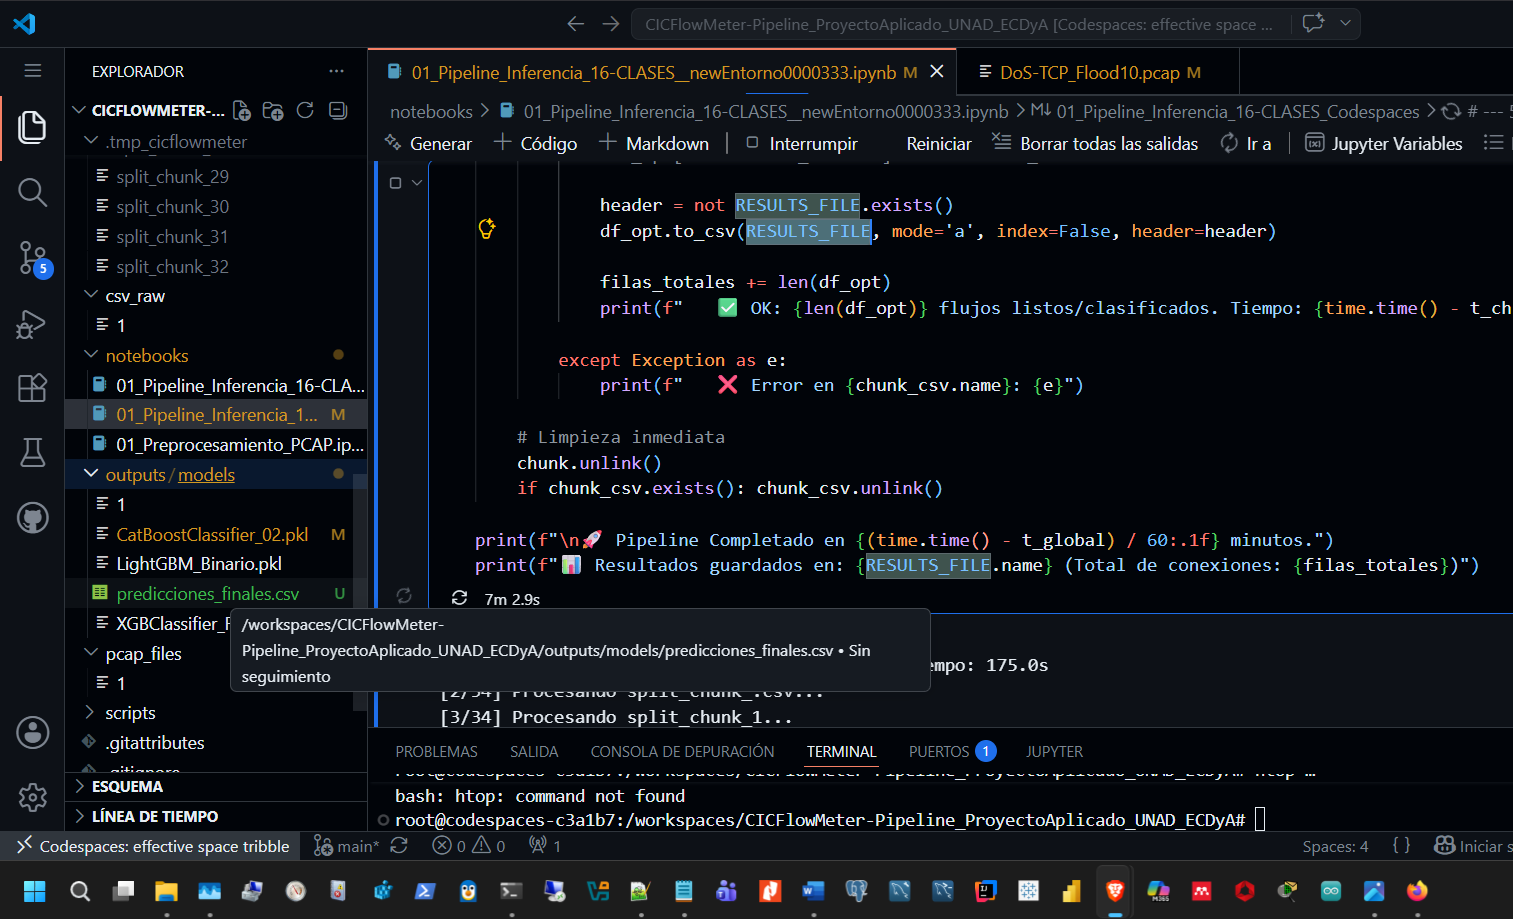

## Detrás de Escena, tras Bambalinas 

1.  `clear_output(wait=True)`: Es el alma de este script. **Borra la celda un microsegundo antes de que Python termine de dibujar el nuevo gráfico**. Esto evita que tu pantalla se llene de cientos de gráficos hacia abajo, *manteniendo un único panel que se actualiza animadamente*.

2.  Lectura Ligera: Se usa `pd.read_csv` sobre el archivo de resultados incremental. Como filtramos todo a solo 40 atributos numéricos altamente optimizados (int32, float32), Pandas puede leer y graficar los datos en milisegundos, manteniendo la UI completamente fluida.

3.  Muestra Dinámica `df_dash.tail(8)`: En lugar de mostrar valores aleatorios globales, te muestra literalmente **los últimos 8 paquetes de red (flujos)** que acaban de ser **procesados y etiquetados por el modelo CatBoost**, con la idea de un efecto real de sistema de Monitoreo de IDS Sistema de Detección de Intrusos.

🚀 PIPELINE EN VIVO | Procesando Fragmento: 24/321
⏱️ Tiempo transcurrido: 29.6 min | 📡 Flujos Analizados: 624,123



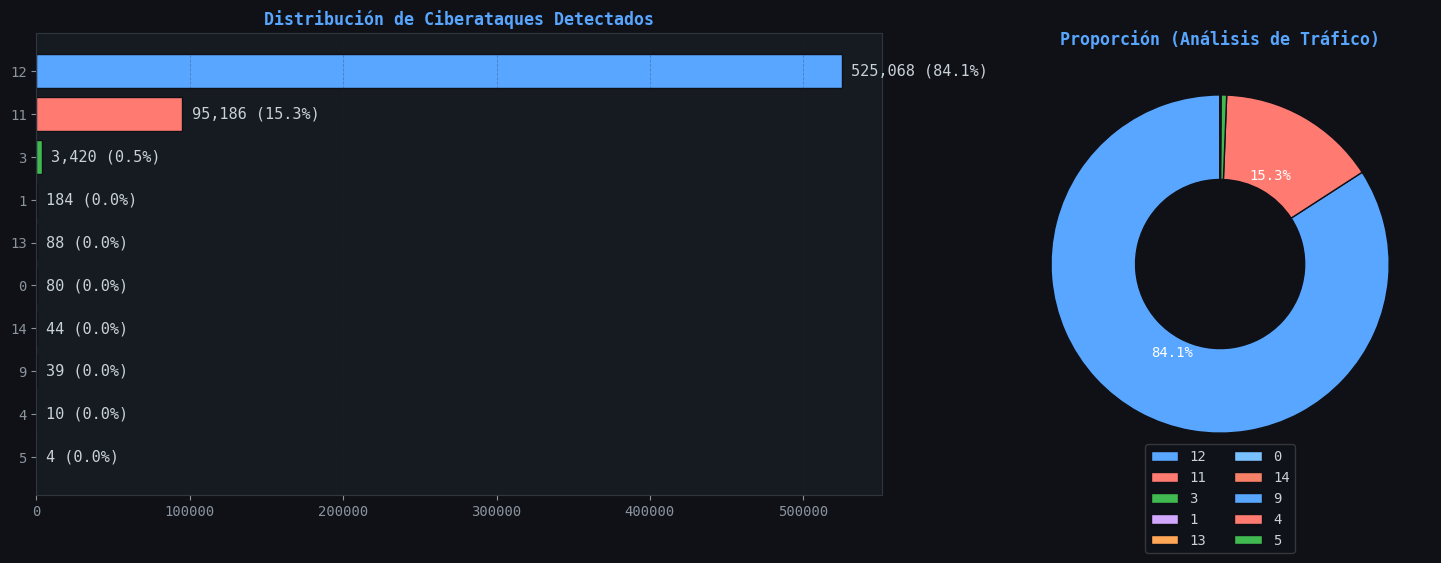


🔍 Últimos flujos detectados:


/tmp/ipykernel_43341/2478281707.py:86: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(muestra.style


,Src Port,Dst Port,Protocol,Flow Bytes/s,Flow Packets/s,Prediccion_Modelo
624115,37315,443,6,0.000000,0.000000,12
624116,37316,443,6,0.000000,0.000000,12
624117,37317,443,6,0.000000,0.000000,12
624118,37318,443,6,0.000000,0.000000,12
624119,37319,443,6,0.000000,0.000000,12
624120,37320,443,6,0.000000,0.000000,12
624121,37321,443,6,0.000000,0.000000,12
624122,37322,443,6,0.000000,0.000000,12


: 

In [25]:
#  5. EL MOTOR STREAMING Y DASHBOARD EN VIVO 

for idx, chunk in enumerate(chunks):
    chunk_csv = chunk.with_suffix(".csv")
    

    # --- A. EXTRACCIÓN ---
    subprocess.run(["cicflowmeter", "-f", str(chunk), "-c", str(chunk_csv)], capture_output=True)
    

    if chunk_csv.exists() and chunk_csv.stat().st_size > 100:
        try:

            # --- B. LIMPIEZA Y ESQUEMA ---
            df_tmp = pd.read_csv(chunk_csv, low_memory=False)
            df_tmp.columns = df_tmp.columns.str.strip()
            
            df_renamed = pd.DataFrame()
            for k, v in MAPEO.items():
                if k in df_tmp.columns: df_renamed[v] = df_tmp[k].values
            
            for col in COLS_40:
                if col not in df_renamed.columns: df_renamed[col] = 0
                    
            df_opt = df_renamed[COLS_40].copy()
            df_opt.replace([np.inf, -np.inf, "inf", "-inf", "Infinity", "-Infinity"], np.nan, inplace=True)
            df_opt.dropna(subset=["Flow Bytes/s", "Flow Packets/s"], inplace=True)
            
            if df_opt.empty: continue
            
            for col in COLS_40:
                if col in COLS_INT32:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0).astype(np.int32)
                else:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0.0).astype(np.float32)



            # --- C. INFERENCIA AL VUELO ---
            predicciones = modelo.predict(df_opt)
            df_opt['Prediccion_Modelo'] = predicciones
            


            # --- D. GUARDADO INCREMENTAL ---
            header = not RESULTS_FILE.exists()
            df_opt.to_csv(RESULTS_FILE, mode='a', index=False, header=header)
            

             
            # --- E. DASHBOARD EN VIVO (ACTUALIZACIÓN VISUAL INMEDIATA) ---
            
            df_dash = pd.read_csv(RESULTS_FILE, low_memory=False)
            n_total = len(df_dash)
            clases = df_dash["Prediccion_Modelo"].value_counts()
            
            # Limpia la salida de la celda antes de redibujar para evitar scroll infinito
            clear_output(wait=True)
            
            print(f"🚀 PIPELINE EN VIVO | Procesando Fragmento: {idx+1}/{len(chunks)}")
            print(f"⏱️ Tiempo transcurrido: {(time.time() - t_global)/60:.1f} min | 📡 Flujos Analizados: {n_total:,}\n")
            

            # --- RENDERIZADO DEL GRÁFICO ---
            fig = plt.figure(figsize=(18, 6), facecolor="#0F1117")
            gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.2)
            clrs = PALETTE[:len(clases)]
            

            # Subplot 1: Barras Horizontales
            ax1 = fig.add_subplot(gs[0, 0])
            bars = ax1.barh(list(clases.index.astype(str)), list(clases.values), color=clrs, edgecolor="#0F1117")
            for bar, cnt in zip(bars, clases.values):
                ax1.text(bar.get_width() + (n_total*0.01), bar.get_y() + bar.get_height()/2, 
                         f"{cnt:,} ({cnt/n_total*100:.1f}%)", va="center", color="#C9D1D9", fontsize=11)
            ax1.set_title("Distribución de Ciberataques Detectados", color="#58A6FF", fontweight="bold")
            ax1.invert_yaxis()
            ax1.grid(axis="x", alpha=0.3)
            

            # Subplot 2: Donut Chart
            ax2 = fig.add_subplot(gs[0, 1])
            wedges, _, autotexts = ax2.pie(clases.values, autopct=lambda p: f"{p:.1f}%" if p > 5 else "", 
                                           colors=clrs, startangle=90, wedgeprops={"width": 0.5, "edgecolor": "#0F1117"})
            for at in autotexts: at.set_color("#FFFFFF")
            ax2.legend(wedges, clases.index, loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=2, framealpha=0.2, labelcolor="#C9D1D9")
            ax2.set_title("Proporción (Análisis de Tráfico)", color="#58A6FF", fontweight="bold")
            
            plt.show()
            

            # --- TABLA DE MUESTRA EN VIVO ---
            print("\n🔍 Últimos flujos detectados:")
            cols_show = ["Src Port", "Dst Port", "Protocol", "Flow Bytes/s", "Flow Packets/s", "Prediccion_Modelo"]
            cols_ok = [c for c in cols_show if c in df_dash.columns]
            

            # Tomamos una muestra de las últimas filas procesadas para ver los ataques entrando
            muestra = df_dash.tail(8)[cols_ok]
            display(muestra.style
                    .set_properties(**{"font-size": "12px", "background-color": "#161B22", "color": "#C9D1D9", "border": "1px solid #30363D"})
                    .applymap(lambda v: "color: #3FB950; font-weight:bold" if str(v).lower() in ["benign","benigno","normal","0"] else "color: #FF7B72; font-weight:bold", subset=["Prediccion_Modelo"]))

        except Exception as e:
            print(f"⚠️ Aviso en {chunk_csv.name}: {e}")
            

    # Limpieza inmediata de disco para proteger la RAM
    chunk.unlink()
    if chunk_csv.exists(): chunk_csv.unlink()


print("\n" + "═"*70)
print(f"✅ ANÁLISIS COMPLETADO EXITOSAMENTE.")
print(f"📊 Archivo maestro guardado en: {RESULTS_FILE.name}")
print("═"*70)

**El Primer Dashboard, Falta el Mapeo de Ataques de Nuemeros a Nombre**

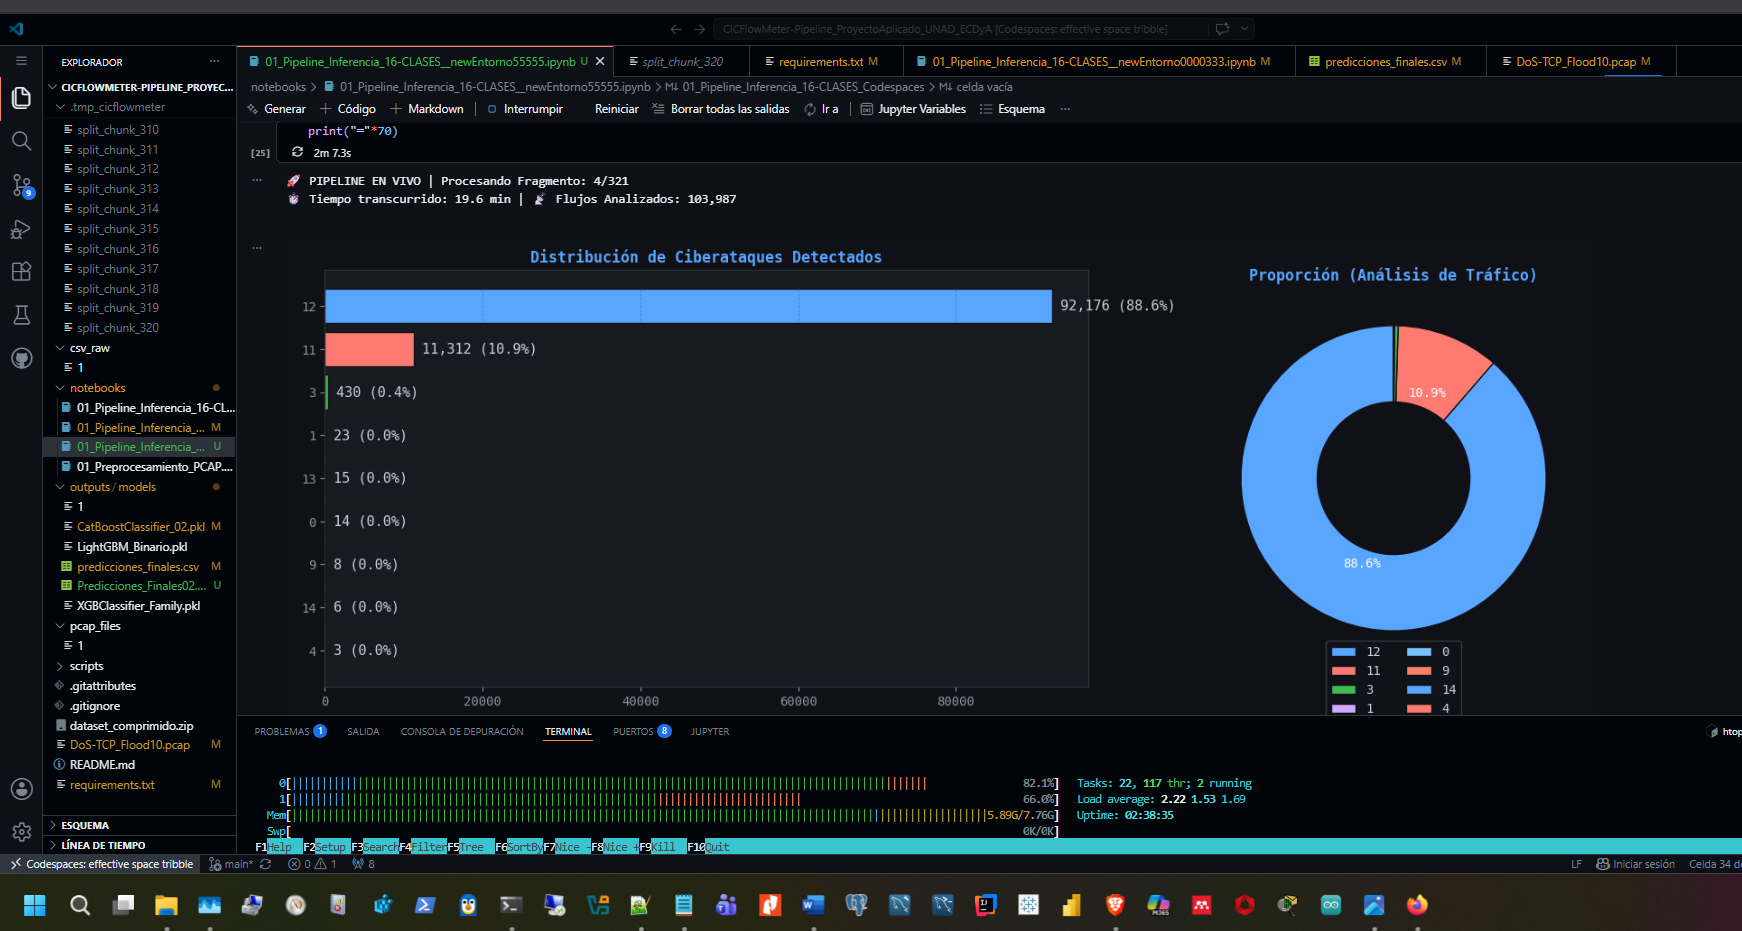